## Pima Hindistanlıları üzrə Diabet Proqnozlaşdırılması

### Layihənin məqsədi

Bu layihənin məqsədi xəstələrin tibbi göstəricilərinə əsasən onların diabet xəstəliyinə tutulub-tutulmayacağını proqnozlaşdırmaqdır.

Modelin qurulması üçün XGBoost Classifier alqoritmindən istifadə ediləcək. Modelin parametrləri Grid Search və Randomized Search üsulları ilə optimallaşdırılacaq.

### Pima Hindistanlıları üzrə Diabet Proqnozlaşdırılması

1. Layihə haqqında ümumi məlumat
2. Datasetin təsviri
3. Kitabxanaların daxil edilməsi
4. Datasetin yüklənməsi
5. Datasetin ilkin araşdırılması
6. Məlumatların təmizlənməsi
7. Xüsusiyyətlərin və hədəf dəyişənin ayrılması
8. Təlim və test məlumatlarının yaradılması
9. XGBoost modelinin qurulması
10. Grid Search ilə parametrlərin optimallaşdırılması
11. Randomized Search ilə parametrlərin optimallaşdırılması
12. Modellərin qiymətləndirilməsi
13. Nəticələrin müqayisəsi
14. Yekun nəticə

In [1]:
# Məlumatların işlənməsi
import pandas as pd
import numpy as np
# Vizual qrafiklərin qurulması
import matplotlib.pyplot as plt
import seaborn as sns
# Datanın təlim və test hissələrinə bölünməsi
from sklearn.model_selection import train_test_split
# Parametrlərin optimallaşdırılması
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# Modelin qiymətləndirilməsi
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
# XGBoost modeli
from xgboost import XGBClassifier

In [2]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

#### Hədəf dəyişənin paylanması

Bu qrafik datasetdə diabet olan və olmayan şəxslərin sayını göstərir.

In [9]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

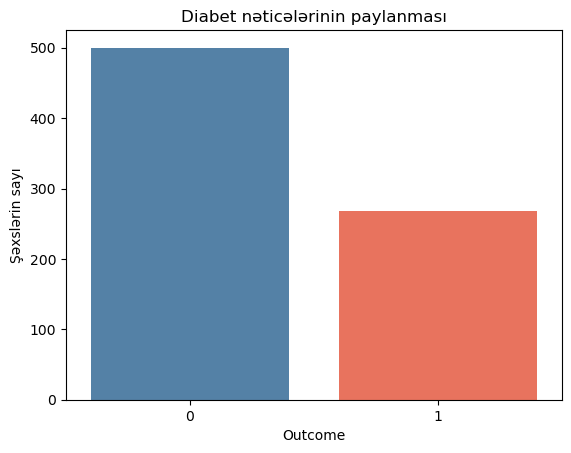

In [78]:
sns.countplot(
    data=df,
    x="Outcome",
    hue="Outcome",
    palette=["steelblue", "tomato"],
    legend=False
)
plt.title("Diabet nəticələrinin paylanması")
plt.xlabel("Outcome")
plt.ylabel("Şəxslərin sayı")
plt.show()

#### Kənar dəyərlərin yoxlanılması

Boxplot vasitəsilə rəqəmsal sütunlardakı potensial kənar dəyərlər vizual şəkildə yoxlanılır.

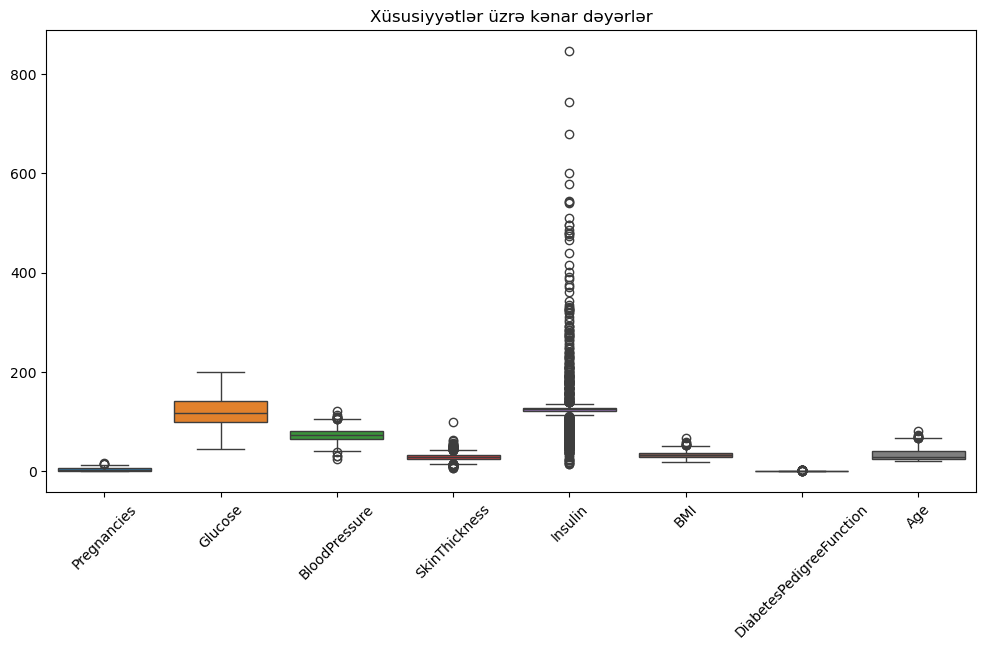

In [79]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop("Outcome", axis=1))
plt.title("Xüsusiyyətlər üzrə kənar dəyərlər")
plt.xticks(rotation=45)
plt.show()

### *Kənar dəyərlərin təhlili*

Boxplot nəticəsinə əsasən xüsusilə **Insulin** sütununda çox sayda və yüksək kənar dəyərlər müşahidə olunur. **Pregnancies**, **BloodPressure**, **SkinThickness**, **BMI**, **DiabetesPedigreeFunction** və **Age** sütunlarında da müəyyən kənar dəyərlər mövcuddur.

**Glucose** sütununda isə nəzərəçarpacaq kənar dəyər görünmür. Qrafikdəki nöqtələr potensial kənar dəyərləri göstərir. Lakin tibbi məlumatlarda belə yüksək və aşağı göstəricilər real ola biləcəyi üçün onları araşdırmadan datasetdən silməyəcəyik.

### Sıfır dəyərlərin yoxlanılması və təmizlənməsi

Bəzi sütunlarda sıfır dəyəri tibbi baxımdan mümkün deyil. Buna görə həmin sıfırlar çatışmayan məlumat kimi qəbul edilir və sütunun median dəyəri ilə əvəz edəcəyik..
1. **Glucose = 0** → Qlükoza səviyyəsi sıfır ola bilməz.

2. **BloodPressure = 0** → Qan təzyiqi sıfır ola bilməz.

3. **BMI = 0** → Bədən kütlə indeksi sıfır ola bilməz.

4. **SkinThickness = 0** və **Insulin = 0** → Bu göstəricilər çox güman ki, ölçülməyib və ya qeyd edilməyib.

In [22]:
zero_columns=["Glucose",
              "BloodPressure",
              "SkinThickness",
              "Insulin",
              "BMI" ]

In [23]:
(df[zero_columns]==0).sum() 

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [18]:
df[zero_columns]=df[zero_columns].replace(0,np.nan)

In [19]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

#### Çatışmayan dəyərlərin medianla doldurulması

Sıfırdan `NaN` dəyərinə çevrilmiş məlumatları hər sütunun median dəyəri ilə əvəz edəcəyik. Median kənar dəyərlərdən daha az təsirləndiyi üçün istifadə olunur.

In [24]:
for column in zero_columns:
    df[column]=df[column].fillna(df[column].median())

In [25]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

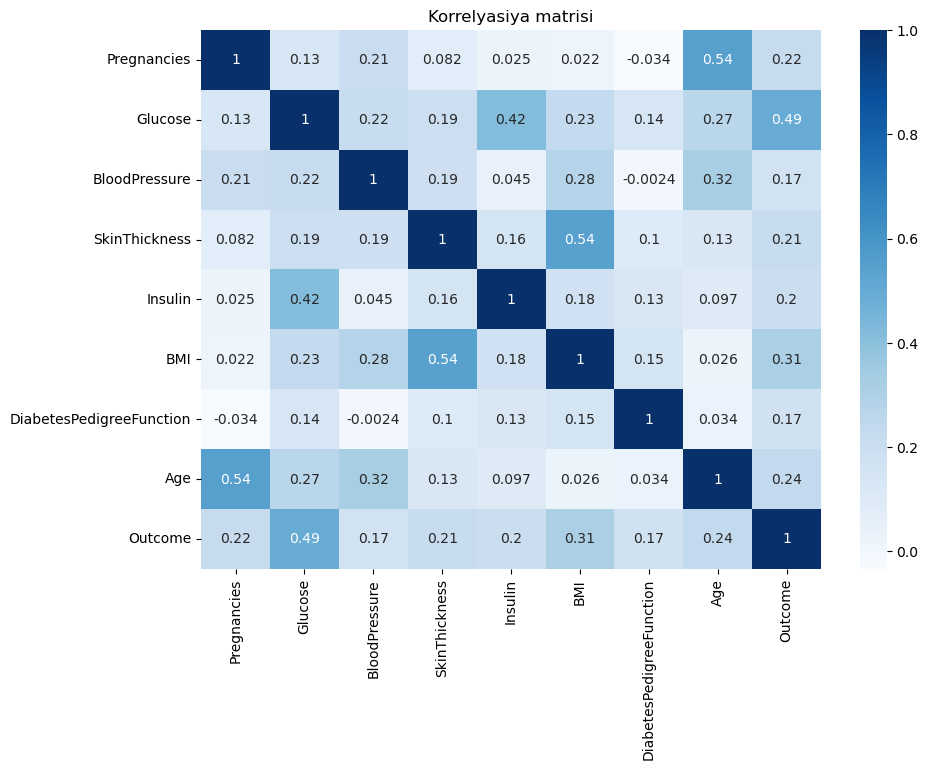

In [42]:
correlation_matrix= df.corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues" )
plt.title("Korrelyasiya matrisi")
plt.show()

#### Xüsusiyyətlərin və hədəf dəyişənin ayrılması

Bu mərhələdə diabetin proqnozlaşdırılması üçün istifadə ediləcək xüsusiyyətlər `X`, proqnozlaşdırılacaq `Outcome` sütunu isə `y` dəyişəninə mənimsədilir.

In [31]:
X=df.drop("Outcome", axis=1)
y=df["Outcome"]

#### Datasetin təlim və test hissələrinə bölünməsi

Datasetin 80%-i modelin öyrədilməsi, 20%-i isə modelin yoxlanılması üçün istifadə ediləcək.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


#### İlkin XGBoost modelinin qurulması

İlk olaraq standart parametrlərlə XGBoost Classifier modeli qurulur və təlim məlumatları üzərində öyrədilir.

In [34]:
xgb=XGBClassifier( random_state=42, eval_metric="logloss")

In [35]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [36]:
y_pred=xgb.predict(X_test)

In [39]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),3))
print(classification_report(y_test, y_pred))

Accuracy: 0.773
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



#### Grid Search ilə parametrlərin optimallaşdırılması

Grid Search verilmiş bütün parametr kombinasiyalarını yoxlayaraq model üçün ən yaxşı parametrləri müəyyən edir.

In [46]:
grid_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

In [53]:
grid_search=GridSearchCV(
    estimator=XGBClassifier(
          random_state=42,
          eval_metric="logloss" ),
    param_grid=grid_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1 )   

In [54]:
grid_search.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [55]:
print("Ən yaxşı parametrlər:", grid_search.best_params_)
print("Ən yaxşı CV nəticəsi:", round(grid_search.best_score_, 3))

Ən yaxşı parametrlər: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Ən yaxşı CV nəticəsi: 0.762


In [57]:
grid_pred=grid_search.predict(X_test)
grid_accuracy=accuracy_score(y_test, grid_pred)

In [66]:
print("Grid Search Accuracy:", round(grid_accuracy, 3))
print(classification_report(y_test, grid_pred))

Grid Search Accuracy: 0.727
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



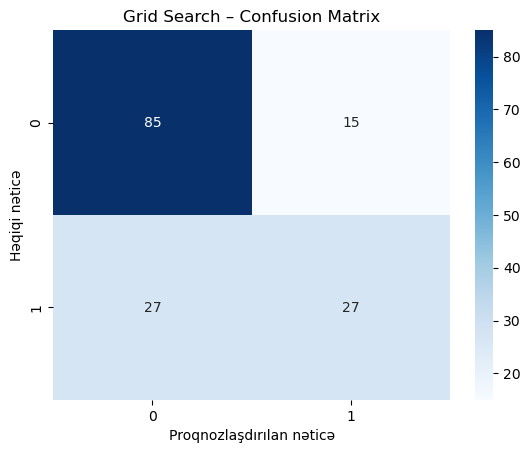

In [70]:
cm = confusion_matrix(y_test, grid_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Proqnozlaşdırılan nəticə")
plt.ylabel("Həqiqi nəticə")
plt.title("Grid Search – Confusion Matrix")
plt.show()

#### Randomized Search ilə parametrlərin optimallaşdırılması

Randomized Search bütün kombinasiyaları yoxlamaq əvəzinə parametr kombinasiyalarından təsadüfi seçimlər edir. Buna görə daha sürətli işləyə bilər.

In [59]:
random_params = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [60]:
random_search= RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss" ),
    param_distributions=random_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1 )


In [61]:
random_search.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [62]:
print("Ən yaxşı parametrlər:", random_search.best_params_)
print("Ən yaxşı CV nəticəsi:", round(random_search.best_score_, 3))

Ən yaxşı parametrlər: {'subsample': 1.0, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Ən yaxşı CV nəticəsi: 0.774


In [63]:
random_pred = random_search.predict(X_test)
random_accuracy = accuracy_score(y_test, random_pred)

In [64]:
print("Randomized Search Accuracy:", round(random_accuracy, 3))
print(classification_report(y_test, random_pred))

Randomized Search Accuracy: 0.753
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



#### Ən yaxşı model üçün qarışıqlıq matrisinin qurulması

Qarışıqlıq matrisi modelin düzgün və səhv proqnozlarının sayını göstərir.

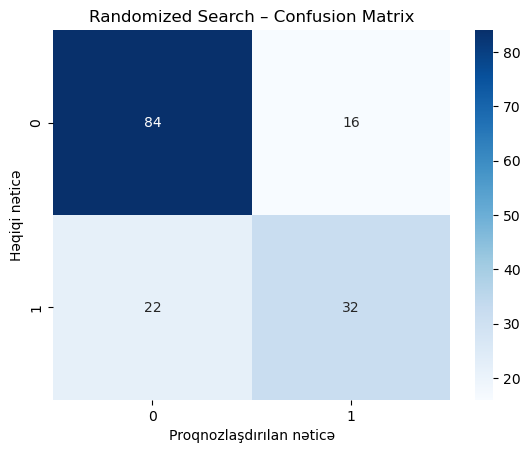

In [65]:
cm = confusion_matrix(y_test, random_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Proqnozlaşdırılan nəticə")
plt.ylabel("Həqiqi nəticə")
plt.title("Randomized Search – Confusion Matrix")
plt.show()

## Modellərin müqayisəsi

In [71]:
base_accuracy = accuracy_score(y_test, y_pred)

In [76]:
results = pd.DataFrame({
    "Model": [
        "İlkin XGBoost",
        "Grid Search",
        "Randomized Search"],
    "Accuracy": [
        base_accuracy,
        grid_accuracy,
        random_accuracy ]
})
results["Accuracy"] = results["Accuracy"].round(3)
results

,Model,Accuracy
0,İlkin XGBoost,0.773
1,Grid Search,0.727
2,Randomized Search,0.753


### Yekun nəticə

Bu layihədə diabet xəstəliyinin proqnozlaşdırılması üçün ilkin XGBoost, Grid Search və Randomized Search modelləri quruldu.

İlkin XGBoost modeli 77.3%, Grid Search modeli 72.7%, Randomized Search modeli isə 75.3% accuracy nəticəsi göstərdi.

Test datasında ən yüksək nəticəni 77.3% accuracy ilə ilkin XGBoost modeli göstərdi. Buna görə accuracy göstəricisinə əsasən ən yaxşı model ilkin XGBoost modeli seçildi. Parametrlərin optimallaşdırılması bu layihədə test accuracy nəticəsini yüksəltmədi.